In [ ]:
'''
Machine Learning
Dataset: Heart Failure Clinical Records
Reason: Classic, lightweight dataset for classification, clustering, and visualization
url:
Alternate url:
Platform: Google Colab
Concepts covered:
Logistic Regression: a strong baseline for binary classification.
Decision Tree: easy to interpret and useful for non-linear splits.
Random Forest: usually stronger than a single tree because it averages many trees.
Gradient Boosting: often performs well on tabular data by building trees sequentially.
'''

In [1]:
# Install libraries and dependencies
!pip -q install ucimlrepo pyspark tensorflow scikit-learn seaborn matplotlib pandas

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, mean_squared_error
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.stats import beta

print("libraries ready")

libraries ready


In [2]:
# Set up
plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")
np.random.seed(42)
tf.random.set_seed(42)
print("set up complete")

set up complete


In [3]:
# Load dataset and print shape
heart = fetch_ucirepo(id=519)
X = heart.data.features
y = heart.data.targets

df = pd.concat([X, y], axis=1)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

target_col = y.columns[0]
df[target_col] = df[target_col].astype(int)
print("dataset ready")

Dataset shape: (299, 13)

First 5 rows:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  death_event  
0        0     4            1  


In [4]:
# Basic statistical analysis
print("\nSummary statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df[target_col].value_counts())



Summary statistics:
              age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.000000   
25%            30.0

/tmp/ipykernel_6903/1909406752.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y="ejection_fraction", data=df, ax=axes[0, 1], palette="Set2")
/tmp/ipykernel_6903/1909406752.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, ax=axes[1, 1], palette="Set3")


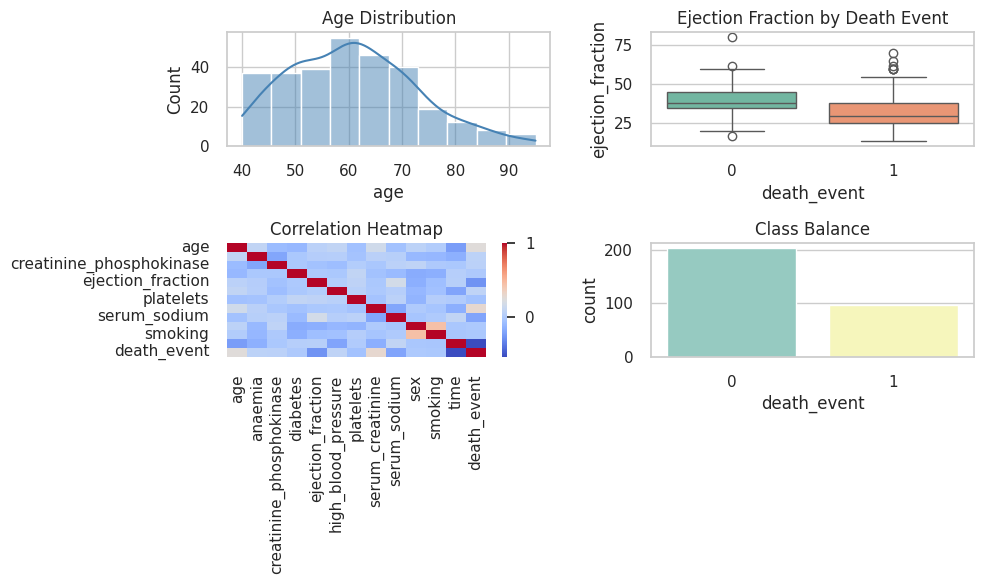

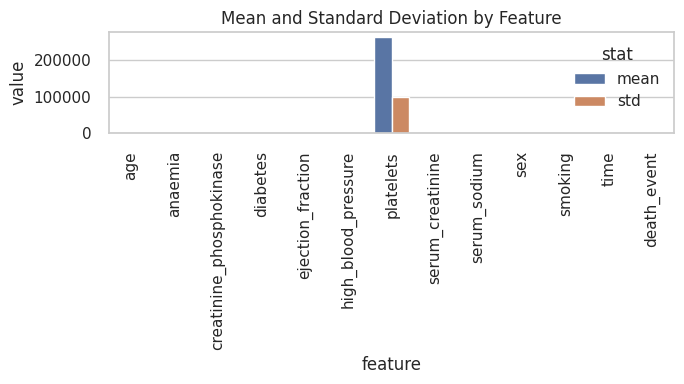

In [7]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

sns.histplot(df["age"], kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Age Distribution")

sns.boxplot(x=target_col, y="ejection_fraction", data=df, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Ejection Fraction by Death Event")

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", ax=axes[1, 0])
axes[1, 0].set_title("Correlation Heatmap")

sns.countplot(x=target_col, data=df, ax=axes[1, 1], palette="Set3")
axes[1, 1].set_title("Class Balance")

plt.tight_layout()
plt.show()

summary = df.describe().T[["mean", "std"]].reset_index().rename(columns={"index": "feature"})
summary_long = summary.melt(id_vars="feature", value_vars=["mean", "std"], var_name="stat", value_name="value")

plt.figure(figsize=(7, 4))
sns.barplot(data=summary_long, x="feature", y="value", hue="stat")
plt.xticks(rotation=90)
plt.title("Mean and Standard Deviation by Feature")
plt.tight_layout()
plt.show()



In [8]:
# Features
feature_cols = [c for c in df.columns if c != target_col]
X = df[feature_cols].copy()
y = df[target_col].copy()
print("features ready")

features ready



Logistic Regression
Accuracy: 0.8166666666666667
ROC AUC: 0.858793324775353
[[38  3]
 [ 8 11]]
              precision    recall  f1-score   support

           0       0.83      0.93      0.87        41
           1       0.79      0.58      0.67        19

    accuracy                           0.82        60
   macro avg       0.81      0.75      0.77        60
weighted avg       0.81      0.82      0.81        60


Decision Tree
Accuracy: 0.6666666666666666
ROC AUC: 0.5750962772785623
[[30 11]
 [ 9 10]]
              precision    recall  f1-score   support

           0       0.77      0.73      0.75        41
           1       0.48      0.53      0.50        19

    accuracy                           0.67        60
   macro avg       0.62      0.63      0.62        60
weighted avg       0.68      0.67      0.67        60


Random Forest
Accuracy: 0.8166666666666667
ROC AUC: 0.8825417201540436
[[38  3]
 [ 8 11]]
              precision    recall  f1-score   support

           0 

/tmp/ipykernel_6903/887945108.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accs.keys()), y=list(accs.values()), palette="viridis")


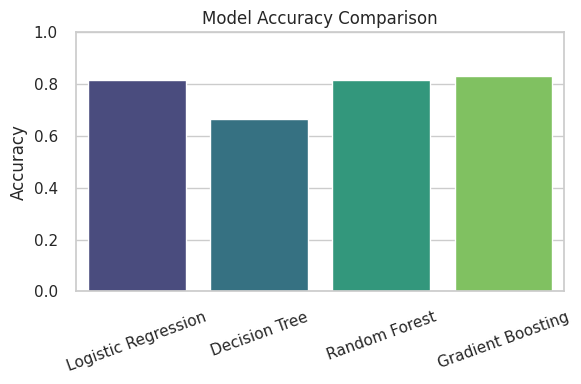

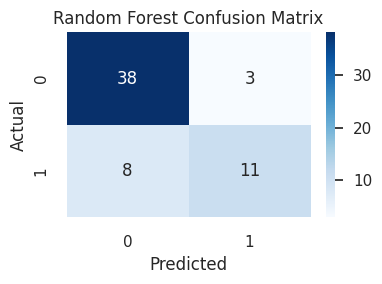

In [10]:
# Supervised Learning - Classification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

logit = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=42))
])
logit.fit(X_train, y_train)
pred_logit = logit.predict(X_test)
prob_logit = logit.predict_proba(X_test)[:, 1]

tree = DecisionTreeClassifier(random_state=42, max_depth=5)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)
prob_tree = tree.predict_proba(X_test)[:, 1]

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
prob_rf = rf.predict_proba(X_test)[:, 1]

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
prob_gb = gb.predict_proba(X_test)[:, 1]

def show_metrics(name, y_true, pred, prob):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, pred))
    print("ROC AUC:", roc_auc_score(y_true, prob))
    print(confusion_matrix(y_true, pred))
    print(classification_report(y_true, pred))

show_metrics("Logistic Regression", y_test, pred_logit, prob_logit)
show_metrics("Decision Tree", y_test, pred_tree, prob_tree)
show_metrics("Random Forest", y_test, pred_rf, prob_rf)
show_metrics("Gradient Boosting", y_test, pred_gb, prob_gb)

accs = {
    "Logistic Regression": accuracy_score(y_test, pred_logit),
    "Decision Tree": accuracy_score(y_test, pred_tree),
    "Random Forest": accuracy_score(y_test, pred_rf),
    "Gradient Boosting": accuracy_score(y_test, pred_gb),
}

plt.figure(figsize=(6, 4))
sns.barplot(x=list(accs.keys()), y=list(accs.values()), palette="viridis")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, pred_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



Regression section (illustrative):
MSE: 130.37084489990585
Sample predictions: [38.83727738 37.85359804 30.65382687 46.06703544 39.98412849]


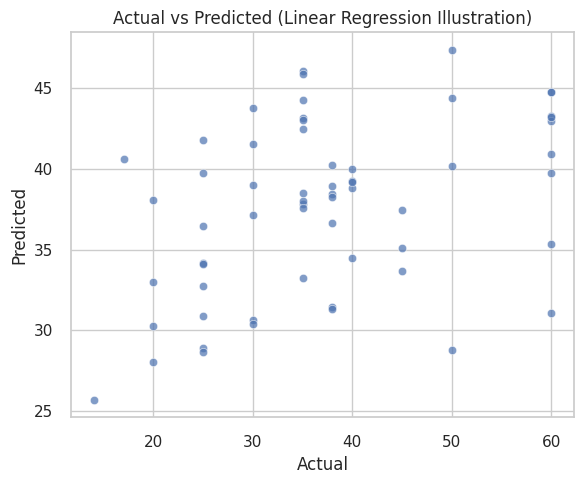

In [11]:
# Regression
# This dataset is classification-first; regression is illustrative.
y_reg = df["ejection_fraction"]
X_reg = df.drop(columns=["ejection_fraction"])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])
reg.fit(X_train_r, y_train_r)
reg_pred = reg.predict(X_test_r)

print("\nRegression section (illustrative):")
print("MSE:", mean_squared_error(y_test_r, reg_pred))
print("Sample predictions:", reg_pred[:5])

plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test_r, y=reg_pred, alpha=0.7)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Linear Regression Illustration)")
plt.tight_layout()
plt.show()


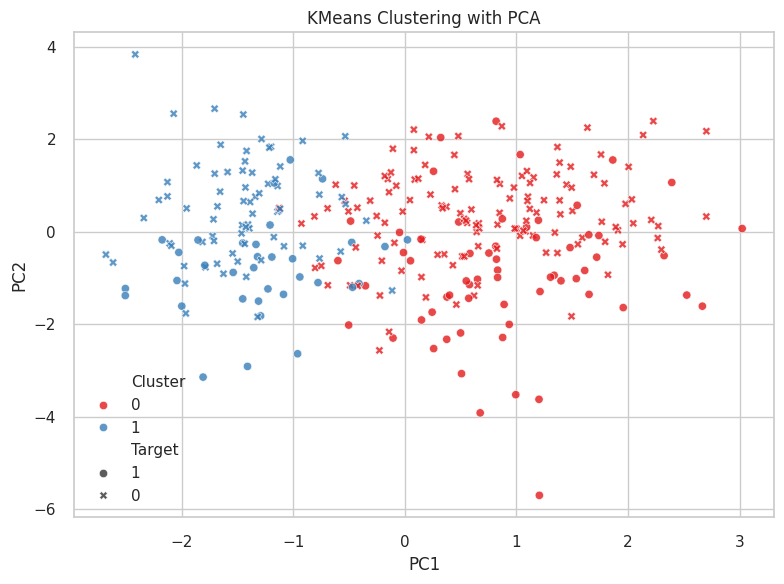

In [12]:
# Unsupervised Learning - Clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

cluster_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": clusters.astype(str),
    "Target": y.astype(str).values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=cluster_df, x="PC1", y="PC2", hue="Cluster", style="Target", palette="Set1", alpha=0.8)
plt.title("KMeans Clustering with PCA")
plt.tight_layout()
plt.show()


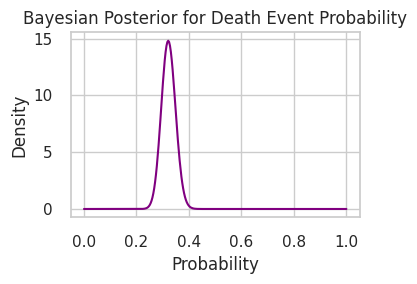


Posterior mean probability: 0.3222591362126246


In [14]:
# Bayesian modeling section
successes = int(y.sum())
failures = int((1 - y).sum())
post_a = 1 + successes
post_b = 1 + failures

x_vals = np.linspace(0, 1, 300)
posterior = beta.pdf(x_vals, post_a, post_b)

plt.figure(figsize=(4, 3))
plt.plot(x_vals, posterior, color="purple")
plt.title("Bayesian Posterior for Death Event Probability")
plt.xlabel("Probability")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

print("\nPosterior mean probability:", post_a / (post_a + post_b))



TensorFlow test accuracy: 0.7833333611488342


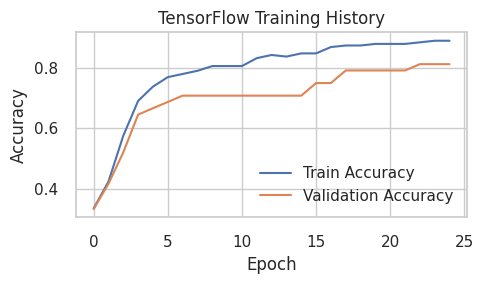

In [16]:
# TensorFlow model
X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(
    X_scaled, y.values, test_size=0.2, random_state=42, stratify=y
)

tf_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_tf.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

tf_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = tf_model.fit(
    X_train_tf, y_train_tf,
    validation_split=0.2,
    epochs=25,
    batch_size=16,
    verbose=0
)

tf_loss, tf_acc = tf_model.evaluate(X_test_tf, y_test_tf, verbose=0)
print("\nTensorFlow test accuracy:", tf_acc)

plt.figure(figsize=(5, 3))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("TensorFlow Training History")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
# PySpark section
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler as SparkStandardScaler
from pyspark.ml.classification import LogisticRegression as SparkLogisticRegression
from pyspark.ml.classification import DecisionTreeClassifier as SparkDecisionTreeClassifier
from pyspark.ml.classification import RandomForestClassifier as SparkRandomForestClassifier
from pyspark.ml.classification import GBTClassifier
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator

spark = SparkSession.builder.master("local[*]").appName("HeartFailureDataset").getOrCreate()
spark_df = spark.createDataFrame(df)

print("\nPySpark shape:", (spark_df.count(), len(spark_df.columns)))

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
scaler_sp = SparkStandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)

train_sp, test_sp = spark_df.randomSplit([0.8, 0.2], seed=42)

spark_lr = SparkLogisticRegression(featuresCol="features", labelCol=target_col, maxIter=50)
spark_dt = SparkDecisionTreeClassifier(featuresCol="features", labelCol=target_col)
spark_rf = SparkRandomForestClassifier(featuresCol="features", labelCol=target_col, numTrees=100)
spark_gbt = GBTClassifier(featuresCol="features", labelCol=target_col, maxIter=50)

pipeline_lr = SparkPipeline(stages=[assembler, scaler_sp, spark_lr])
pipeline_dt = SparkPipeline(stages=[assembler, scaler_sp, spark_dt])
pipeline_rf = SparkPipeline(stages=[assembler, scaler_sp, spark_rf])
pipeline_gbt = SparkPipeline(stages=[assembler, scaler_sp, spark_gbt])

m_lr = pipeline_lr.fit(train_sp)
m_dt = pipeline_dt.fit(train_sp)
m_rf = pipeline_rf.fit(train_sp)
m_gbt = pipeline_gbt.fit(train_sp)

p_lr = m_lr.transform(test_sp)
p_dt = m_dt.transform(test_sp)
p_rf = m_rf.transform(test_sp)
p_gbt = m_gbt.transform(test_sp)

evaluator = BinaryClassificationEvaluator(labelCol=target_col, rawPredictionCol="rawPrediction", metricName="areaUnderROC")

print("\nPySpark AUC scores:")
print("Logistic Regression:", evaluator.evaluate(p_lr))
print("Decision Tree:", evaluator.evaluate(p_dt))
print("Random Forest:", evaluator.evaluate(p_rf))
print("Gradient Boosting:", evaluator.evaluate(p_gbt))

spark.stop()



PySpark shape: (299, 13)

PySpark AUC scores:
Logistic Regression: 0.8895463510848126
Decision Tree: 0.7672583826429981
Random Forest: 0.9329388560157791
Gradient Boosting: 0.9526627218934911


In [18]:
# End
print("\nCompleted heart failure dataset workflow.")


Completed heart failure dataset workflow.
